In [1]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/home/wychen/workspace/vllm-dynamic/examples/logs/'
BASELINE_DATA_PATH = f'{DATA_PATH}dllm_org_128'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']
scheduling_policy = 'fcfs'
wt = 1.0

In [2]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR):
    output_tokens, reqs, mean_tpot, p99_tpot,  mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []

    filename = f'{DATA_DIR}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_recompute_{store_cache_layer}_{scheduling_policy}_wt{wt}.log'
    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft_, p99_ttft_, mean_itl_, p99_itl_ = [], [], [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean TTFT' in line:
                mean_ttft_.append(float(line.split()[-1]))
            if 'P99 TTFT' in line:
                p99_ttft_.append(float(line.split()[-1]))    
            if 'Mean ITL' in line:
                mean_itl_.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl_.append(float(line.split()[-1]))    

    output_tokens.append(np.mean(output_tokens_tgt))
    reqs.append(np.mean(reqs_tgt))
    mean_tpot.append(np.mean(mean_tpot_))
    p99_tpot.append(np.mean(p99_tpot_))
    mean_ttft.append(np.mean(mean_ttft_))
    p99_ttft.append(np.mean(p99_ttft_))
    mean_itl.append(np.mean(mean_itl_))
    p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl 

In [3]:
# plot throughput
def get_norm_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_ttft, baseline_p99_ttft, baseline_mean_itl, baseline_p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, BASELINE_DATA_PATH)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [(baseline_mean_tpot-mean_tpot[i]) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [(baseline_p99_tpot-p99_tpot[i]) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_ttft_imp = [(baseline_mean_ttft-mean_ttft[i]) / baseline_mean_ttft *100 for i in range(len(mean_ttft))]
    p99_ttft_imp = [(baseline_p99_ttft-p99_ttft[i]) / baseline_p99_ttft *100 for i in range(len(p99_ttft))]
    mean_itl_imp = [(baseline_mean_itl-mean_itl[i]) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [(baseline_p99_itl-p99_itl[i]) / baseline_p99_itl *100 for i in range(len(p99_itl))]

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp
    

In [194]:
# 绘制柱状图，对比swap和recompute的性能提升
def plot_bar_(rate1, rate2, store_cache_layer, req_rate):
    print('rate1:', rate1)
    print('rate2:', rate2)
    fig = plt.figure(figsize=(6, 2.5), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    ax.bar(np.arange(8), rate1, bar_width, label='0.5:0.5', color='skyblue', hatch=hatches[0])
    ax.bar(np.arange(8)+bar_width, rate2, bar_width, label='0.25:0.75', color='lightcoral', hatch=hatches[1])
    # bar3 = ax.bar(np.arange(8)+bar_width*2, rate3, bar_width, label='0.25:0.75', color='lightgreen', hatch=hatches[2])
    # 将数值标注在柱状图上
    for x, y in zip(np.arange(8), rate1):
        if y >= 0: ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=20, fontsize=8)
        else: ax.text(x, y, f'{y:.2f}', ha='center', va='top', rotation=70, fontsize=8)
    for x, y in zip(np.arange(8)+bar_width, rate2):
        if y >= 0: ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=20, fontsize=8)
        else: ax.text(x, y, f'{y:.2f}', ha='center', va='top', rotation=70, fontsize=8)
    # for x, y in zip(np.arange(8)+bar_width*2, rate3):
    #     if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
    #     else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    ax.set_xticks(np.arange(8)+bar_width)
    ax.set_xticklabels(['out_toks', 'reqs', 'avg_tpot', 'p99_tpot', 'avg_ttft', 'p99_ttft', 'avg_itl', 'p99_itl'], rotation=0)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(plt.MultipleLocator(30))
    # ax.set_ylim(min(min(rate1), min(rate2), min(rate3))*1.4, max(max(rate1), max(rate2), max(rate3))*1.4)
    ax.set_ylim(min(min(rate1), min(rate2))*1.4, max(max(rate1), max(rate2))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    ax.title.set_text(f'req_rate={req_rate},cache_layer={store_cache_layer}')
    # ax.legend(bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()    

# 绘制柱状图，对比swap和recompute的性能提升
def plot_bar(rate1, rate2, store_cache_layer, req_rate):
    print('rate1:', rate1)
    print('rate2:', rate2)
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    filtered_rate1 = [rate1[0], rate1[3],rate1[5]]
    filtered_rate2 = [rate2[0], rate2[3],rate2[5]]
    ax.bar(np.arange(3), filtered_rate1, bar_width, label='0.5:0.5', color=plt.cm.tab20b(0/5), hatch=hatches[0], edgecolor='white')
    ax.bar(np.arange(3)+bar_width, filtered_rate2, bar_width, label='0.25:0.75', color=plt.cm.tab20b(1/5), hatch=hatches[1], edgecolor='white')
    for x, y in zip(np.arange(3), filtered_rate1):
        if y >= 0: ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', rotation=70, fontsize=10)
        else: ax.text(x, y, f'{y:.1f}', ha='center', va='top', rotation=70, fontsize=10)
    for x, y in zip(np.arange(3)+bar_width, filtered_rate2):
        if y >= 0: ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', rotation=70, fontsize=10)
        else: ax.text(x, y, f'{y:.1f}', ha='center', va='top', rotation=70, fontsize=10)
    ax.set_xticklabels(['Output token', 'P99 TPOT', 'P99 TTFT'], rotation=0)
    ax.set_xticks(np.arange(3)+0.5*bar_width)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    # ax.yaxis.set_major_locator(plt.MultipleLocator(30))
    # ax.set_ylim(min(min(rate1), min(rate2), min(rate3))*1.4, max(max(rate1), max(rate2), max(rate3))*1.4)
    ax.set_ylim(min(min(rate1), min(rate2))*1.8, max(max(rate1), max(rate2))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    # ax.title.set_text(f'req_rate={req_rate},cache_layer={store_cache_layer}')
    # ax.legend(bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    if req_rate == 500:
        ax.legend(loc='lower left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    else:
        ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)    
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'./{store_cache_layer}_{req_rate}_hfusion.pdf')
    plt.show()        

In [ ]:
def plot_bar(rate1, rate2, store_cache_layer, req_rate):
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    filtered_rate1 = [rate1[0], rate1[3],rate1[5]]
    filtered_rate2 = [rate2[0], rate2[3],rate2[5]]
    ax.bar(np.arange(3), filtered_rate1, bar_width, label='0.5:0.5', color=plt.cm.tab20b(0/5), hatch=hatches[0], edgecolor='white')
    ax.bar(np.arange(3)+bar_width, filtered_rate2, bar_width, label='0.25:0.75', color=plt.cm.tab20b(1/5), hatch=hatches[1], edgecolor='white')
    for x, y in zip(np.arange(3), filtered_rate1):
        if y >= 0: ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', rotation=70, fontsize=10)
        else: ax.text(x, y, f'{y:.1f}', ha='center', va='top', rotation=70, fontsize=10)
    for x, y in zip(np.arange(3)+bar_width, filtered_rate2):
        if y >= 0: ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', rotation=70, fontsize=10)
        else: ax.text(x, y, f'{y:.1f}', ha='center', va='top', rotation=70, fontsize=10)
    ax.set_xticklabels(['Output token', 'P99 TPOT', 'P99 TTFT'], rotation=0)
    ax.set_xticks(np.arange(3)+0.5*bar_width)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylim(min(min(rate1), min(rate2))*1.8, max(max(rate1), max(rate2))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    if req_rate == 500:
        ax.legend(loc='lower left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    else:
        ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)    
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'./{store_cache_layer}_{req_rate}_hfusion.pdf')
    plt.show()        

rate1: [2.2236708457771748, 3.2692307692307936, -4.51516563585528, -3.155126763628428, 2.9505986229019716, 1.8746405856518655, -0.02749950893731818, -5.314858753792618]
rate2: [-0.3767263465882452, 0.769230769230787, -4.727611624163329, -2.9331090638714348, 2.90030551946499, 1.8858904118937914, -1.5222942447456267, -4.778478658057699]


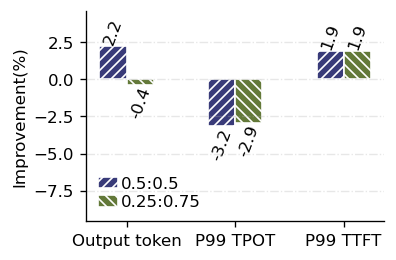

rate1: [-12.334825853641853, 9.188118811881179, -4.054893544925728, 2.9419912947178406, -2.260811067817412, -0.4944467363098103, 25.205968941726432, 21.170716163466906]
rate2: [-20.121680281641993, 0.0, -11.91744633321412, -3.761170928108411, -9.547805303067209, -8.680471089227503, 19.735038317189936, 12.130964709631144]


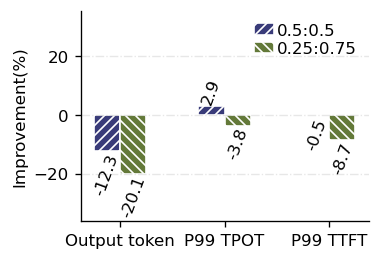

rate1: [-11.068260425440405, 0.7228915662650609, -16.082031920370707, -12.444027032375853, -20.95274880780661, -16.582302356696278, -8.106842787275845, -16.47277468686024]
rate2: [-8.524936829089077, 3.6144578313253044, -6.738524903961658, 0.337494832769082, -3.405527402136622, -1.2719109292942055, -1.818333821009068, -6.456903824936727]


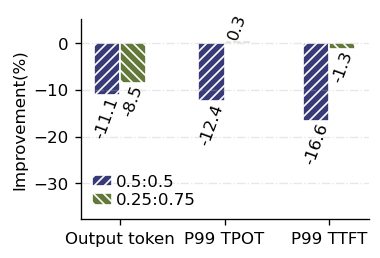

rate1: [32.462069052642256, 6.744186046511621, 5.21279574408512, -29.524615523353003, 0.3875515030153232, 13.933584192573326, 0.4667484040079539, 37.46992796822418]
rate2: [29.78132066652351, 4.457364341085271, 2.2749545009100016, -35.45509409879506, -5.312107931088394, 9.327461196164574, -2.0716188221367413, 36.4970404182217]


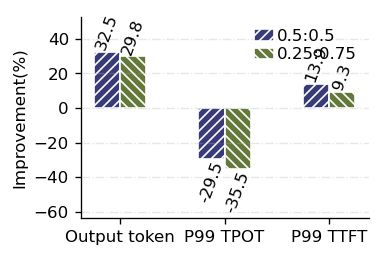

rate1: [78.42904769211454, 29.44543828264757, 29.110895389225266, -9.825367453792325, -90.64624189312302, -211.87868034027025, 32.66875882629843, 25.050658081621062]
rate2: [76.59194576573812, 29.159212880143105, 31.728325094128945, -4.618317667921296, -78.04346461827437, -195.2274784149525, 34.8611329044406, 29.858678155477698]


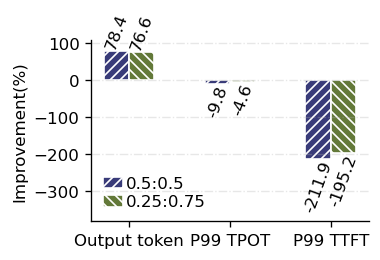

In [195]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.7
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
# store_cache_layers = [0.05]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 300, 300, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, 300) 


rate1: [80.22652220190497, 60.935672514619895, 33.84411384579234, 31.874186269831455, 31.452933673242484, 30.800553480829034, 34.92969449060463, 33.54779203546983]
rate2: [5.668513413935203, 5.847953216374261, 7.230337990186479, 9.083732466139981, 19.578606360665432, 15.521764790485705, 6.600728620733742, 10.32824155730675]


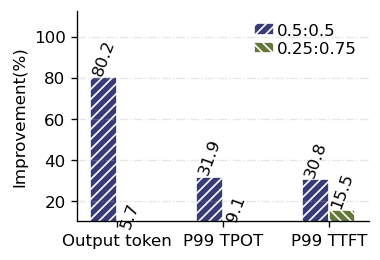

rate1: [0.8361378670070805, -8.928571428571418, 14.788868140473454, 16.74801260026319, 14.253637423006493, 16.333952965588804, 13.802057325476877, -16.152857741209562]
rate2: [-15.132151560868042, -20.98214285714285, 1.758741943256423, 2.6778834416106423, -0.3472282337273271, 1.0433058101331472, 2.607859782283045, 10.3602436409845]


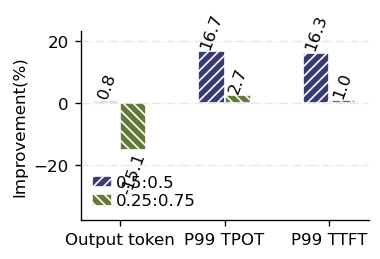

rate1: [11.608840597604626, 15.384615384615365, 12.380527347751004, 19.84349982209573, 12.569884274811463, 12.174036628456886, 12.100389728848223, 8.03109220309331]
rate2: [-4.639461661933564, -4.5857988165680545, -2.928012788621932, 6.739097802882053, 2.774894503619713, 1.0744968120402352, -4.455623427955445, -4.5520058844578815]


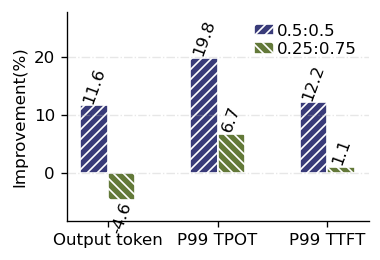

rate1: [9.276382879034253, 15.254237288135586, 8.970318859299926, 9.465334304060342, 15.52407051274652, 15.720119034101984, 5.197396237051648, 8.773459751797095]
rate2: [-5.9718049775376905, -5.5084745762712, -3.692952468974263, -4.331496312033037, 3.340097718039823, 3.0469018765156735, -9.540157494186465, -6.910878373796285]


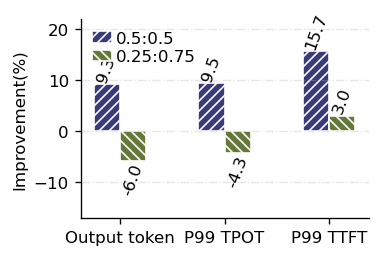

rate1: [-9.663347158767927, -6.438095238095223, 0.25315857276239956, 5.041041389680569, -0.24552200773160013, -7.339253573623298, -6.195443458404686, 3.3102695812335625]
rate2: [6.137229719771771, -0.5714285714285762, -3.3931758282019975, -10.000050234259094, -26.741227361433957, -74.32948127869807, -1.489438995277391, 4.942772727518255]


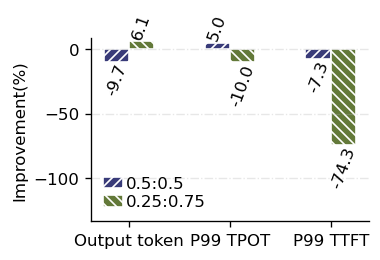

In [196]:
gpu_utilization=0.6
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 100, 100, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate=100)    

rate1: [0.9611149562700625, -1.8633540372670823, -11.557683825845869, -3.243401755069239, -10.547452999279734, -10.871676440883542, 2.3343725311971766, 3.4109514280516646]
rate2: [5.718712640785263, 4.658385093167689, 7.622960115934732, 11.898672744090948, -11.514920553381044, -11.87571702529227, 6.207154325130184, -25.979827380591438]


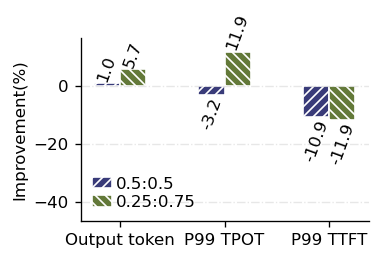

rate1: [-4.4811095169775115, -2.6487523992322437, 7.2012999042481205, -0.22292981492532715, -15.058805681050394, -13.874160086893466, -2.2815041257179836, -13.010985228739417]
rate2: [-12.854136776661893, -3.2629558541266785, 8.691011599591985, -10.798074508410584, -21.42582534057075, -20.859373881542307, -2.439129240652969, -19.31277785745017]


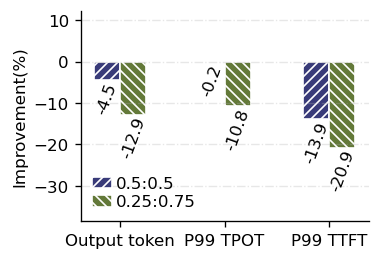

rate1: [18.394130269260085, -15.839243498817973, 20.87834326288, 6.410014944385297, -17.148449030403388, -13.903248290233892, 11.585632751147939, 47.07265288763956]
rate2: [17.196649823492784, -14.042553191489368, 21.448853369678574, 24.973472845227505, -13.015225212507037, -11.438647141308826, 7.1501523409003145, 35.09147383369913]


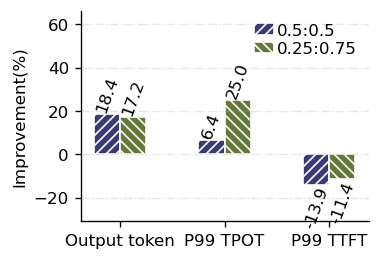

rate1: [-9.420785410838269, 9.240924092409236, -25.906787055889414, -31.57084789208051, -13.848088144395444, -6.899999029684843, -7.27141573246297, -52.425926427932446]
rate2: [-0.558491348046836, 14.30143014301429, -34.57394468614432, -66.58083437407913, -13.724909575396223, -35.32336633482866, -1.5065512511233936, -53.4159234460137]


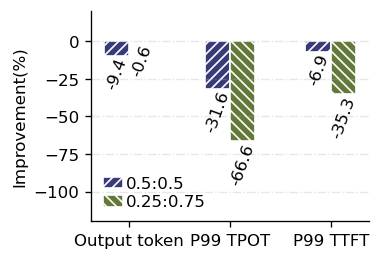

rate1: [-5.410445043338915, -7.734241908006796, 0.6001515741176989, -5.671961735025785, 0.33580509080919124, -1.1719062310982162, -0.5461995783888731, -1.3559160557863903]
rate2: [-9.434773108019522, -11.822827938671194, -2.806579136027519, -11.280542784692194, -1.8820224719101213, -8.188186184936455, -5.988299107037125, -3.588218170270216]


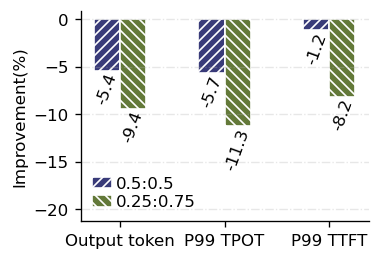

In [197]:
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 200, 200, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, 200)    

rate1: [2.2236708457771748, 3.2692307692307936, -4.51516563585528, -3.155126763628428, 2.9505986229019716, 1.8746405856518655, -0.02749950893731818, -5.314858753792618]
rate2: [-0.3767263465882452, 0.769230769230787, -4.727611624163329, -2.9331090638714348, 2.90030551946499, 1.8858904118937914, -1.5222942447456267, -4.778478658057699]


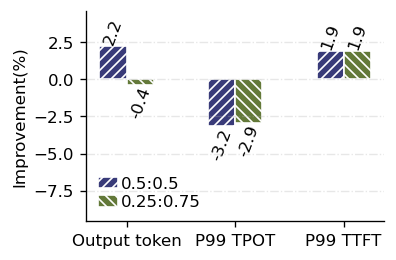

rate1: [-12.334825853641853, 9.188118811881179, -4.054893544925728, 2.9419912947178406, -2.260811067817412, -0.4944467363098103, 25.205968941726432, 21.170716163466906]
rate2: [-20.121680281641993, 0.0, -11.91744633321412, -3.761170928108411, -9.547805303067209, -8.680471089227503, 19.735038317189936, 12.130964709631144]


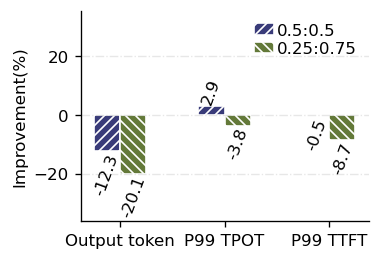

rate1: [-11.068260425440405, 0.7228915662650609, -16.082031920370707, -12.444027032375853, -20.95274880780661, -16.582302356696278, -8.106842787275845, -16.47277468686024]
rate2: [-8.524936829089077, 3.6144578313253044, -6.738524903961658, 0.337494832769082, -3.405527402136622, -1.2719109292942055, -1.818333821009068, -6.456903824936727]


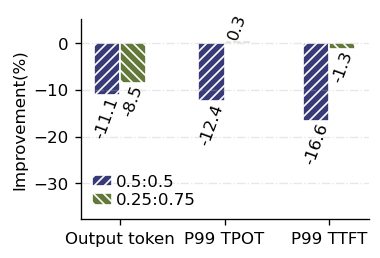

rate1: [32.462069052642256, 6.744186046511621, 5.21279574408512, -29.524615523353003, 0.3875515030153232, 13.933584192573326, 0.4667484040079539, 37.46992796822418]
rate2: [29.78132066652351, 4.457364341085271, 2.2749545009100016, -35.45509409879506, -5.312107931088394, 9.327461196164574, -2.0716188221367413, 36.4970404182217]


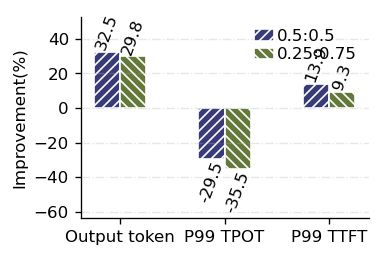

rate1: [78.42904769211454, 29.44543828264757, 29.110895389225266, -9.825367453792325, -90.64624189312302, -211.87868034027025, 32.66875882629843, 25.050658081621062]
rate2: [76.59194576573812, 29.159212880143105, 31.728325094128945, -4.618317667921296, -78.04346461827437, -195.2274784149525, 34.8611329044406, 29.858678155477698]


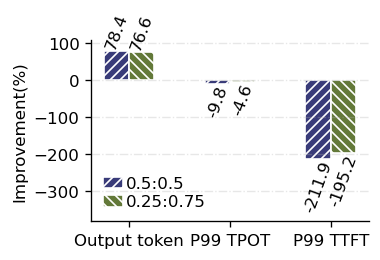

In [198]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.7
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 300, 300, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate=300)    

rate1: [-28.214931581168234, 33.19587628865979, -581.0710461033766, -490.9069220941701, 1.052017822016605, 1.3038990917847315, -50.241660955633705, -790.1526748617699]
rate2: [-0.658116824401702, -0.41237113402063036, 0.3227643047892862, 1.273395248465903, 0.8893377695277871, 1.4498197001546345, -0.6475749643294701, -3.2013346052470992]


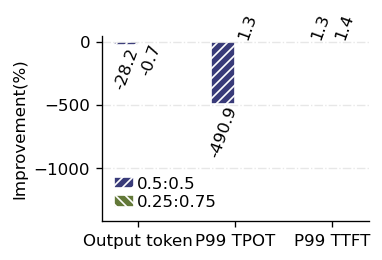

rate1: [-2.807155852031529, 2.857142857142841, -4.523432023373201, -5.512345744511546, 0.8921931045942183, -0.7542783485284578, 0.93142857142856, 19.910972697044922]
rate2: [-6.2031534263189725, 0.023612750885459825, -2.8870247611161353, -3.26453954139832, 0.11877306499011177, -0.7072969425880214, 1.2124675324675342, 4.338032126633269]


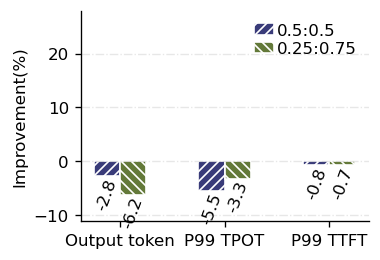

rate1: [-1.1931749425194391, -7.640449438202237, 5.932764376365752, -4.029924056372101, -18.92292941371254, -8.460563389557457, 2.6502365756231323, 10.675893305295034]
rate2: [-2.6783913517002196, -0.5243445692883983, -0.5365468250635198, 1.8561119237432973, -2.9561191339060806, 1.861860915795473, 0.5179605854694066, -1.8801218905886763]


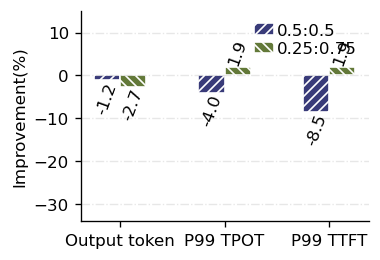

rate1: [7.664151430732644, 5.71428571428572, -5.0111210832325215, -26.838154349398724, -14.886622063020502, -14.663266658344028, 0.14736842105264658, -28.667016126545597]
rate2: [1.691050310868428, 7.857142857142856, -9.484137823389402, -27.974544196433264, -14.883156224035574, -12.30097222463089, 1.3342601787487678, -19.875427831395896]


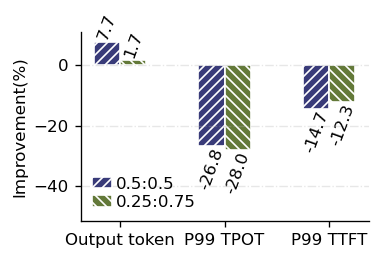

rate1: [-0.0898862078857741, -3.399999999999998, 1.6498870726945447, 19.544840811694044, -2.579437258582596, -1.3194410228621907, 1.6442212341255789, -0.8234169653524556]
rate2: [2.461352118063278, 3.199999999999994, -0.6251196263828738, 6.43531690898774, 1.5225515874018558, 1.4624454758477603, 1.8668628642717666, 2.168697729988058]


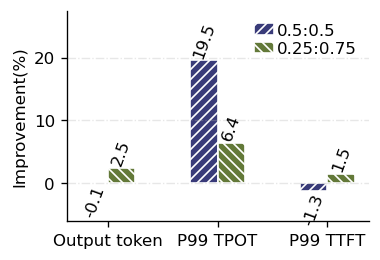

In [199]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.6
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 400, 400, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate=400)    

rate1: [21.670157410740593, 6.124999999999991, 12.240170554712812, 1.2607237094051476, -1.2308444909396448, -1.3329009526534747, 13.00499864133012, 39.127588582504785]
rate2: [11.367280819452189, 6.499999999999992, -13.938464061460254, -37.06681979804892, -7.56616681582038, -6.549692230367249, 3.524326510493372, -14.82498058745571]


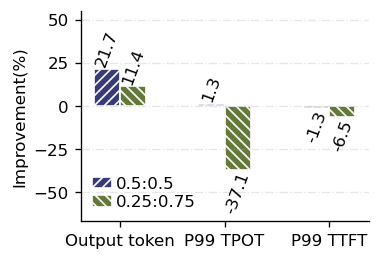

rate1: [1.6804780454451111, -3.7280701754385923, -0.21121759661081532, -6.264588503857628, -1.9118439571311625, -3.5280153693728886, -4.069085207719091, -30.682910337106172]
rate2: [-3.8227264191372368, -1.9736842105263095, -0.7331921169708646, 0.9658512622768101, -0.8029547721452787, -0.192591690264236, -0.8145073019692219, -20.813962587456807]


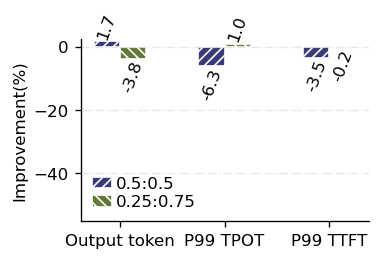

rate1: [4.233016333319113, -0.8658008658008665, 1.5667078809640709, -12.462726727588626, -7.351790720716502, -3.9349766847389738, -0.47382196749734196, -0.9825609354830509]
rate2: [2.899910443942177, -0.7792207792207703, -1.3359360444437043, -4.256302757888997, -3.874550958260841, -0.7580176145463078, -1.270819131298332, -14.43941042969112]


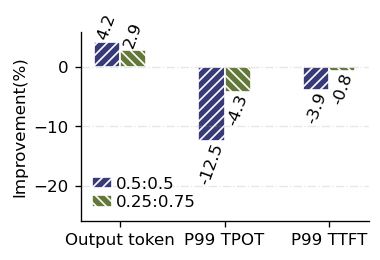

rate1: [9.032233376277157, 17.351215423302584, -6.19970557156147, 3.317254858575791, 2.1940576268731795, 0.23805350447980578, -6.694639871281193, -20.61857177674871]
rate2: [12.27980662525351, 3.0176026823134796, 3.74041527053999, 24.31869307076741, -2.5514305126832735, -3.178348862579982, -1.547990871901661, -13.9912259322447]


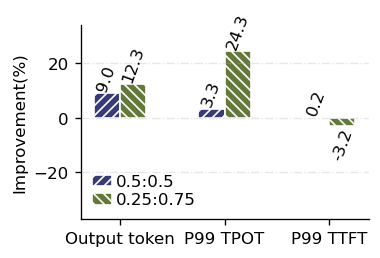

rate1: [1.219852612773553, -2.6022304832713776, -0.46315095660976224, 38.50203534177165, -4.454739318737328, -1.2843310483306098, 0.1766875375246739, 2.7506011792996827]
rate2: [3.292485484591328, -2.4783147459727406, 2.1121331426587164, 46.53204888839026, -6.6719086615412575, -0.8134343999351128, 2.454755982502795, 5.02428508160301]


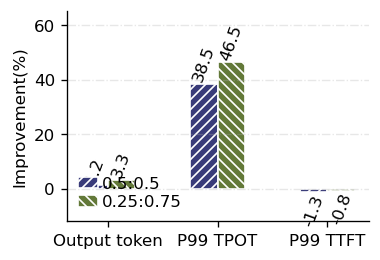

In [200]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.6
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 500, 500, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer, req_rate=500)    